In [114]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from xgboost import XGBRegressor
import scipy.stats as stats


In [115]:
df = pd.read_csv("ds_salaries.csv")

In [116]:
df.head()

,work_year,experience_level,employment_type,job_title,salary,salary_currency,salary_in_usd,employee_residence,remote_ratio,company_location,company_size
0,2023,SE,FT,Principal Data Scientist,80000,EUR,85847,ES,100,ES,L
1,2023,MI,CT,ML Engineer,30000,USD,30000,US,100,US,S
2,2023,MI,CT,ML Engineer,25500,USD,25500,US,100,US,S
3,2023,SE,FT,Data Scientist,175000,USD,175000,CA,100,CA,M
4,2023,SE,FT,Data Scientist,120000,USD,120000,CA,100,CA,M


In [117]:
print(df["job_title"].unique())

<ArrowStringArray>
[                'Principal Data Scientist',
                              'ML Engineer',
                           'Data Scientist',
                        'Applied Scientist',
                             'Data Analyst',
                             'Data Modeler',
                        'Research Engineer',
                       'Analytics Engineer',
           'Business Intelligence Engineer',
                'Machine Learning Engineer',
                          'Data Strategist',
                            'Data Engineer',
                 'Computer Vision Engineer',
                     'Data Quality Analyst',
                  'Compliance Data Analyst',
                           'Data Architect',
        'Applied Machine Learning Engineer',
                             'AI Developer',
                       'Research Scientist',
                   'Data Analytics Manager',
                    'Business Data Analyst',
                   'Applied Data Sci

In [118]:
cat_cols = ["experience_level", "employment_type", "job_title",
            "employee_residence", "company_location", "company_size"]

X = df[["work_year", "experience_level", "employment_type", "job_title",
        "employee_residence", "remote_ratio", "company_location", "company_size"]].copy()
Y = df["salary_in_usd"]

X[cat_cols] = X[cat_cols].astype("category")

X_train, X_test, y_train, y_test = train_test_split(
    X, Y, test_size=0.2, random_state=1
)

model = XGBRegressor(
    enable_categorical=True,
    tree_method="hist",
    n_estimators=500,
    learning_rate=0.05,
    random_state=1,
)
model.fit(X_train, y_train)

,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,True
,eval_metric,None
,feature_types,None


train RMSE: 39,348
test  RMSE: 52,881


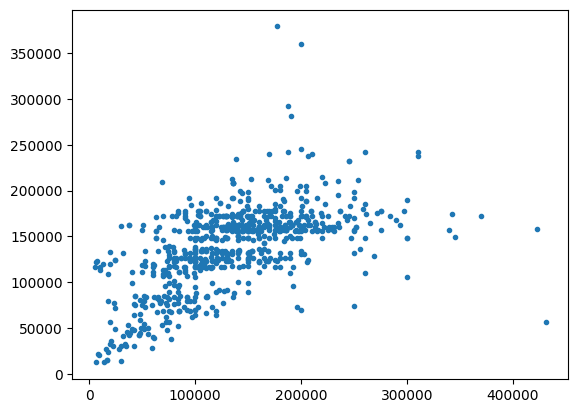

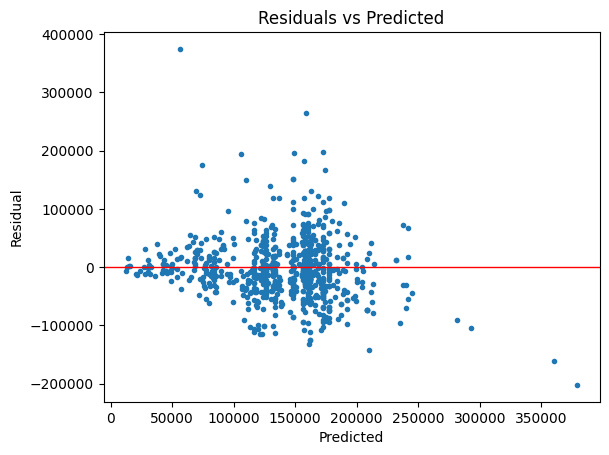

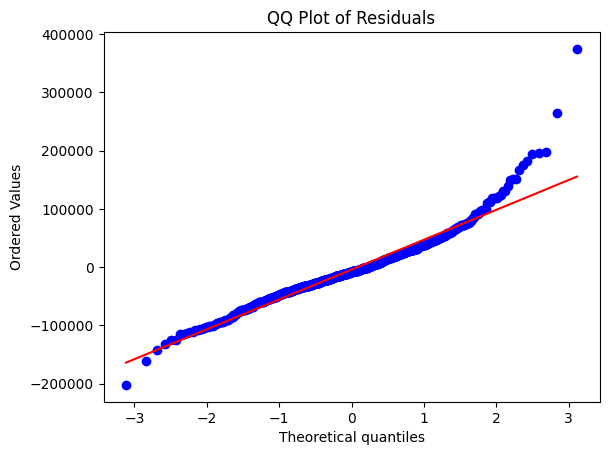

In [119]:
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.metrics import mean_squared_error

pred = model.predict(X_test)


rmse_train = np.sqrt(mean_squared_error(y_train, model.predict(X_train)))
rmse_test  = np.sqrt(mean_squared_error(y_test,  model.predict(X_test)))
print(f"train RMSE: {rmse_train:,.0f}")
print(f"test  RMSE: {rmse_test:,.0f}")

resid = y_test.values - pred

plt.plot(y_test,pred,'.')
plt.show()


plt.figure()
plt.plot(pred, resid, '.')
plt.axhline(0, color='red', lw=1)
plt.xlabel("Predicted")
plt.ylabel("Residual")
plt.title("Residuals vs Predicted")
plt.show()

plt.figure()
stats.probplot(resid, dist="norm", plot=plt)
plt.title("QQ Plot of Residuals")
plt.show()

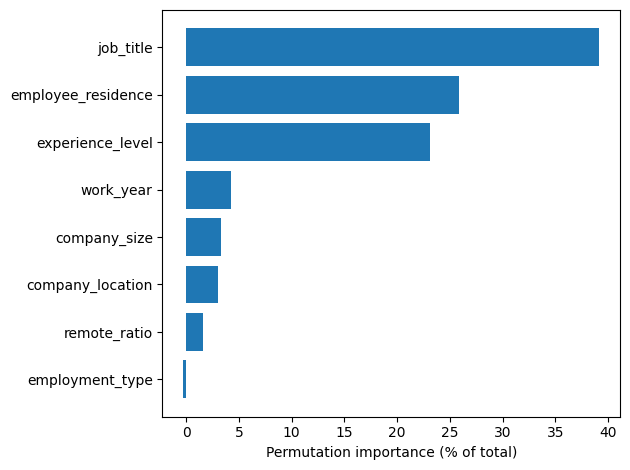

In [120]:
from sklearn.inspection import permutation_importance
import pandas as pd

r = permutation_importance(model, X_test, y_test, n_repeats=50, random_state=0)
pi = pd.Series(r.importances_mean, index=X_test.columns).sort_values()

pi_pct = (pi / pi.sum() * 100)

plt.barh(pi_pct.index, pi_pct.values)
plt.xlabel("Permutation importance (% of total)")
plt.tight_layout()
plt.show()

In [121]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


def counterfactual_mean_prediction_cat(model, X_base, feature, values):
    rows = []

    X_base = X_base.copy()

    if str(X_base[feature].dtype) != "category":
        raise TypeError(f"{feature} must be categorical dtype.")

    categories = X_base[feature].cat.categories

    for v in values:
        if v not in categories:
            raise ValueError(
                f"{v} is not in categories for {feature}. "
                f"Available categories: {list(categories)}"
            )

    observed_pred = model.predict(X_base).mean()

    for v in values:
        X_cf = X_base.copy()

        # Preserve the original category universe and ordering
        X_cf[feature] = pd.Categorical(
            [v] * len(X_cf),
            categories=categories,
            ordered=X_base[feature].cat.ordered
        )

        pred = model.predict(X_cf)

        rows.append({
            "feature": feature,
            "value": v,
            "mean_pred": pred.mean(),
            "median_pred": np.median(pred),
            "p10_pred": np.quantile(pred, 0.10),
            "p90_pred": np.quantile(pred, 0.90),
            "shift_vs_observed": pred.mean() - observed_pred,
        })

    return pd.DataFrame(rows)

In [122]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def counterfactual_prediction(model, X_base, feature, values):
    rows = []

    X_base = X_base.copy()
    observed_pred = model.predict(X_base).mean()

    is_cat = str(X_base[feature].dtype) == "category"

    if is_cat:
        categories = X_base[feature].cat.categories

        for v in values:
            if v not in categories:
                raise ValueError(
                    f"{v} not in categories for {feature}. "
                    f"Available: {list(categories)}"
                )

    for v in values:
        X_cf = X_base.copy()

        if is_cat:
            X_cf[feature] = pd.Categorical(
                [v] * len(X_cf),
                categories=X_base[feature].cat.categories,
                ordered=X_base[feature].cat.ordered
            )
        else:
            X_cf[feature] = v

        pred = model.predict(X_cf)

        rows.append({
            "feature": feature,
            "value": v,
            "mean_pred": pred.mean(),
            "median_pred": np.median(pred),
            "p10_pred": np.quantile(pred, 0.10),
            "p90_pred": np.quantile(pred, 0.90),
            "shift_vs_observed": pred.mean() - observed_pred,
        })

    return pd.DataFrame(rows)

In [123]:
experience_cf = counterfactual_mean_prediction_cat(
    model=model,
    X_base=X_test.copy(),
    feature="experience_level",
    values=["EN", "MI", "SE", "EX"]
)

print(experience_cf)

            feature value      mean_pred    median_pred      p10_pred  \
0  experience_level    EN  104328.179688  111244.953125  59654.632812   
1  experience_level    MI  121780.859375  128109.351562  77296.796875   
2  experience_level    SE  147509.812500  156855.734375  88133.851562   
3  experience_level    EX  159002.015625  164242.281250  98614.976562   

        p90_pred  shift_vs_observed  
0  148290.593750      -35332.757812  
1  161644.625000      -17880.078125  
2  182722.015625        7848.875000  
3  212737.703125       19341.078125  


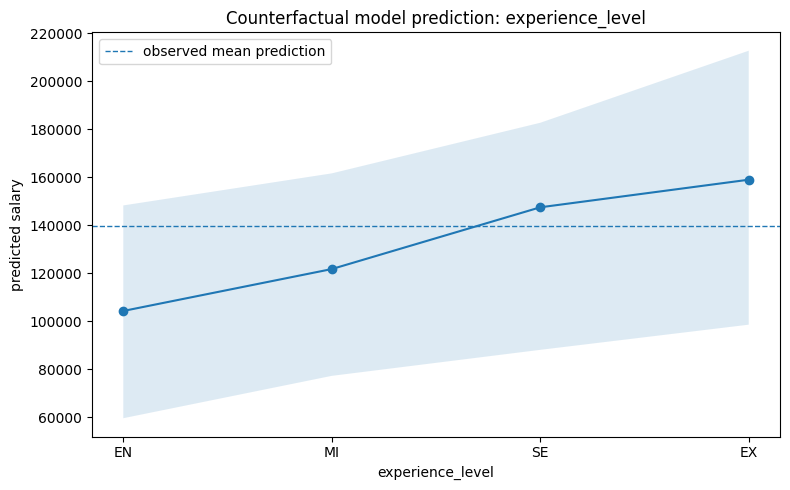

In [124]:
plt.figure(figsize=(8, 5))

plt.plot(
    experience_cf["value"],
    experience_cf["mean_pred"],
    marker="o"
)

plt.fill_between(
    experience_cf["value"],
    experience_cf["p10_pred"],
    experience_cf["p90_pred"],
    alpha=0.15
)

plt.axhline(
    model.predict(X_test).mean(),
    linestyle="--",
    linewidth=1,
    label="observed mean prediction"
)

plt.title("Counterfactual model prediction: experience_level")
plt.xlabel("experience_level")
plt.ylabel("predicted salary")
plt.legend()
plt.tight_layout()
plt.show()

In [125]:
remote_cf = counterfactual_prediction(
    model=model,
    X_base=X_test.copy(),
    feature="remote_ratio",
    values=[0, 50, 100]
)

print(remote_cf)

        feature  value      mean_pred    median_pred      p10_pred  \
0  remote_ratio      0  138945.234375  148169.093750  77311.226562   
1  remote_ratio     50  137141.203125  146445.015625  72783.804688   
2  remote_ratio    100  139947.609375  156402.250000  75469.875000   

        p90_pred  shift_vs_observed  
0  172634.000000        -715.703125  
1  188043.546875       -2519.734375  
2  187618.062500         286.671875  


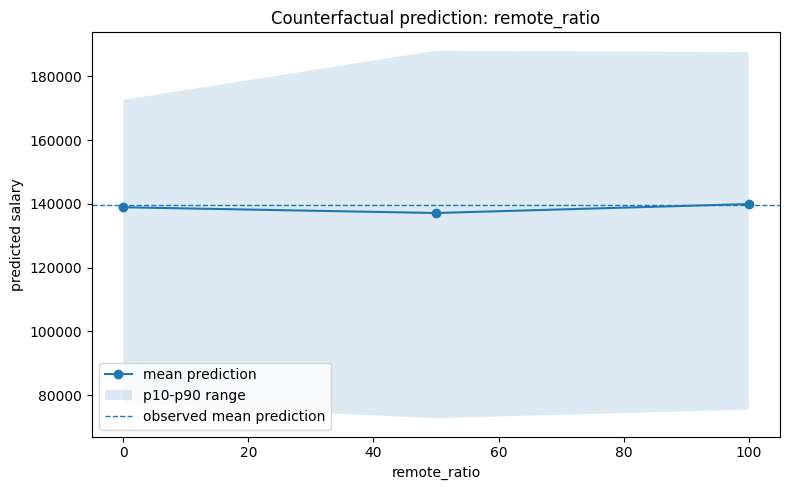

In [126]:
plt.figure(figsize=(8, 5))

plt.plot(
    remote_cf["value"],
    remote_cf["mean_pred"],
    marker="o",
    label="mean prediction"
)

plt.fill_between(
    remote_cf["value"],
    remote_cf["p10_pred"],
    remote_cf["p90_pred"],
    alpha=0.15,
    label="p10-p90 range"
)

plt.axhline(
    model.predict(X_test).mean(),
    linestyle="--",
    linewidth=1,
    label="observed mean prediction"
)

plt.title("Counterfactual prediction: remote_ratio")
plt.xlabel("remote_ratio")
plt.ylabel("predicted salary")
plt.legend()
plt.tight_layout()
plt.show()

In [127]:
def map_job_family(title):
    t = str(title).lower()

    if any(k in t for k in [
        "machine learning", "ml ", "mlops", "ai ",
        "deep learning", "nlp", "computer vision",
        "autonomous"
    ]):
        return "ML/AI"

    if any(k in t for k in [
        "engineer", "architect", "etl", "database",
        "infrastructure", "devops", "cloud", "data modeler"
    ]):
        return "Data Engineering"

    if any(k in t for k in [
        "analyst", "analytics", "bi", "business intelligence",
        "insight", "strategist", "quality", "compliance",
        "finance", "marketing", "product"
    ]):
        return "Analytics/BI"

    if any(k in t for k in [
        "scientist", "science", "research", "applied scientist",
        "consultant", "specialist"
    ]):
        return "Data Science/Research"

    if any(k in t for k in [
        "head", "director", "manager", "lead", "principal", "staff"
    ]):
        return "Leadership/Management"

    return "Other"

In [128]:
df["job_family"] = df["job_title"].apply(map_job_family)

print(df["job_family"].value_counts())

job_family
Data Engineering         1363
Data Science/Research    1136
Analytics/BI              729
ML/AI                     485
Leadership/Management      42
Name: count, dtype: int64


In [129]:
from sklearn.model_selection import train_test_split
from xgboost import XGBRegressor

cat_cols_family = [
    "experience_level",
    "employment_type",
    "job_family",
    "employee_residence",
    "company_location",
    "company_size"
]

X_family = df[
    [
        "work_year",
        "experience_level",
        "employment_type",
        "job_family",
        "employee_residence",
        "remote_ratio",
        "company_location",
        "company_size",
    ]
].copy()

Y = df["salary_in_usd"]

X_family[cat_cols_family] = X_family[cat_cols_family].astype("category")

X_train_f, X_test_f, y_train_f, y_test_f = train_test_split(
    X_family,
    Y,
    test_size=0.2,
    random_state=1
)

model_family = XGBRegressor(
    enable_categorical=True,
    tree_method="hist",
    n_estimators=500,
    learning_rate=0.05,
    random_state=1,
)

model_family.fit(X_train_f, y_train_f)

,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,True
,eval_metric,None
,feature_types,None


In [130]:
job_family_values = list(X_test_f["job_family"].cat.categories)

job_family_cf = counterfactual_prediction(
    model=model_family,
    X_base=X_test_f.copy(),
    feature="job_family",
    values=job_family_values
)

job_family_cf = job_family_cf.sort_values("mean_pred", ascending=False)

print(job_family_cf)

      feature                  value      mean_pred    median_pred  \
4  job_family                  ML/AI  158397.281250  169884.312500   
2  job_family  Data Science/Research  148839.953125  166318.312500   
1  job_family       Data Engineering  138648.078125  157217.031250   
3  job_family  Leadership/Management  118334.804688  113270.289062   
0  job_family           Analytics/BI  112179.406250  122324.125000   

       p10_pred       p90_pred  shift_vs_observed  
4  83050.015625  201932.046875       19927.359375  
2  82488.703125  180655.296875       10370.031250  
1  78485.195312  161459.515625         178.156250  
3  54936.785156  157548.406250      -20135.117188  
0  58175.968750  132557.812500      -26290.515625  


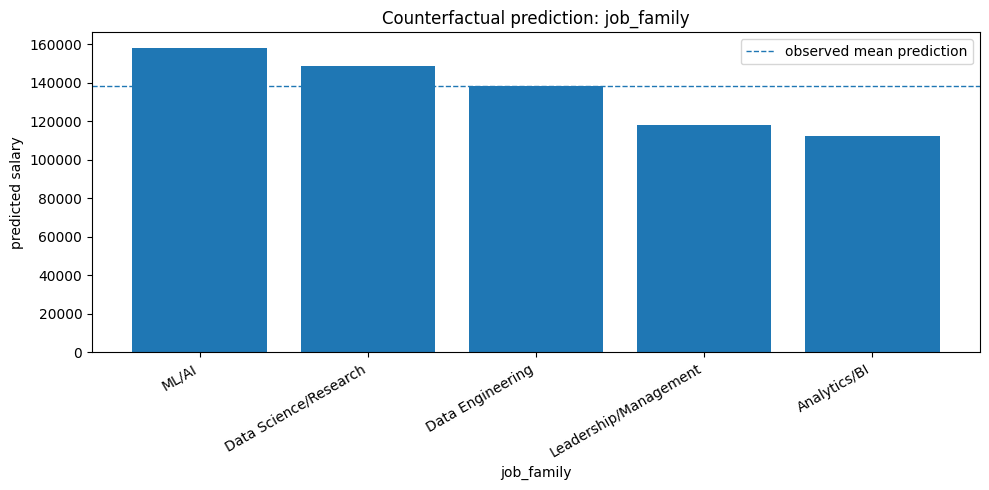

In [131]:
plt.figure(figsize=(10, 5))

plt.bar(
    job_family_cf["value"],
    job_family_cf["mean_pred"]
)

plt.axhline(
    model_family.predict(X_test_f).mean(),
    linestyle="--",
    linewidth=1,
    label="observed mean prediction"
)

plt.title("Counterfactual prediction: job_family")
plt.xlabel("job_family")
plt.ylabel("predicted salary")
plt.xticks(rotation=30, ha="right")
plt.legend()
plt.tight_layout()
plt.show()

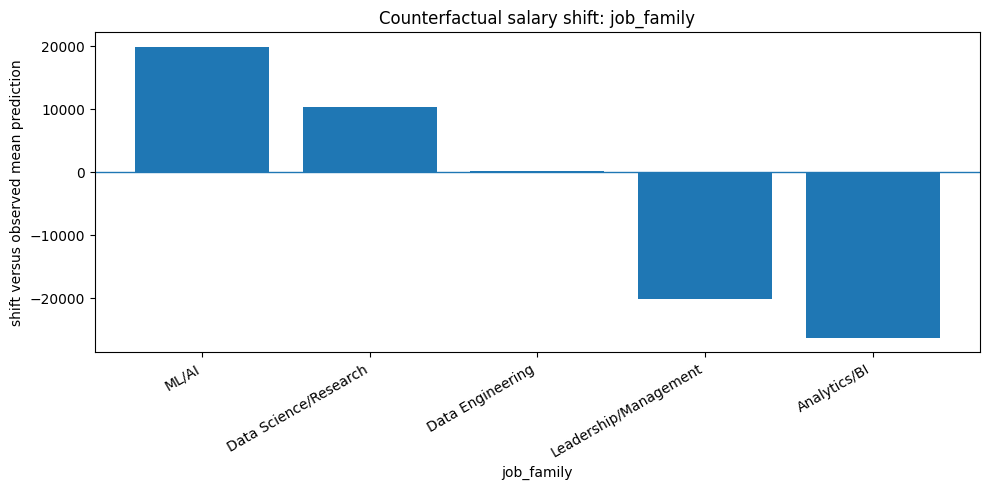

In [132]:
plt.figure(figsize=(10, 5))

plt.bar(
    job_family_cf["value"],
    job_family_cf["shift_vs_observed"]
)

plt.axhline(0, linewidth=1)

plt.title("Counterfactual salary shift: job_family")
plt.xlabel("job_family")
plt.ylabel("shift versus observed mean prediction")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

In [133]:
X_train_xgb = X_train.copy()
X_test_xgb = X_test.copy()
y_train_salary = y_train.copy()
y_test_salary = y_test.copy()

# For the linear model use separate names to avoid overwriting
# X_train_lin, X_test_lin, y_train_log, y_test_log

In [134]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score


# ============================================================
# 1. Prepare data
# ============================================================

cat_cols = [
    "experience_level",
    "employment_type",
    "job_title",
    "employee_residence",
    "company_location",
    "company_size",
]

num_cols = [
    "work_year",
    "remote_ratio",
]

feature_cols = num_cols + cat_cols

D = df[feature_cols + ["salary_in_usd"]].dropna().copy()

# Make experience level ordered so EN is baseline when using drop_first=True
D["experience_level"] = pd.Categorical(
    D["experience_level"],
    categories=["EN", "MI", "SE", "EX"],
    ordered=True
)

# Log salary makes multiplicative priors easy
D["log_salary"] = np.log(D["salary_in_usd"])

X_raw = D[feature_cols].copy()
y = D["log_salary"].copy()

X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X_raw,
    y,
    test_size=0.2,
    random_state=1
)


# ============================================================
# 2. Design matrix
# ============================================================

def make_design_matrix(X_raw, train_columns=None):
    X = X_raw.copy()

    X_dum = pd.get_dummies(
        X,
        columns=cat_cols,
        drop_first=True,
        dtype=float
    )

    # Add intercept
    X_dum.insert(0, "const", 1.0)

    if train_columns is not None:
        X_dum = X_dum.reindex(columns=train_columns, fill_value=0.0)

    return X_dum


X_train = make_design_matrix(X_train_raw)
X_test = make_design_matrix(X_test_raw, train_columns=X_train.columns)

print(X_train.shape)
print(X_train.columns[:20])

(3004, 230)
Index(['const', 'work_year', 'remote_ratio', 'experience_level_MI',
       'experience_level_SE', 'experience_level_EX', 'employment_type_FL',
       'employment_type_FT', 'employment_type_PT', 'job_title_AI Developer',
       'job_title_AI Programmer', 'job_title_AI Scientist',
       'job_title_Analytics Engineer', 'job_title_Applied Data Scientist',
       'job_title_Applied Machine Learning Engineer',
       'job_title_Applied Machine Learning Scientist',
       'job_title_Applied Scientist',
       'job_title_Autonomous Vehicle Technician',
       'job_title_Azure Data Engineer', 'job_title_BI Analyst'],
      dtype='str')


In [135]:
# ============================================================
# 3. ML estimator
# ============================================================

def fit_ml(X, y):
    Xv = X.values
    yv = y.values

    theta_ml = np.linalg.pinv(Xv.T @ Xv) @ (Xv.T @ yv)

    return pd.Series(theta_ml, index=X.columns)


# ============================================================
# 4. MAP / Bayesian Gaussian-prior estimator
# ============================================================

def fit_map_gaussian_prior(X, y, mu0, prior_sd, sigma2=None):
    """
    Prior:
        theta ~ N(mu0, diag(prior_sd^2))

    Likelihood:
        y | X, theta ~ N(X theta, sigma2 I)

    MAP:
        argmax posterior.
    """

    Xv = X.values
    yv = y.values

    mu0 = pd.Series(mu0, index=X.columns).astype(float)
    prior_sd = pd.Series(prior_sd, index=X.columns).astype(float)

    if sigma2 is None:
        theta_ml = fit_ml(X, y)
        resid = yv - Xv @ theta_ml.values
        sigma2 = np.mean(resid ** 2)

    prior_var = prior_sd.values ** 2
    prior_precision = np.diag(1 / prior_var)

    posterior_precision = (Xv.T @ Xv) / sigma2 + prior_precision
    posterior_rhs = (Xv.T @ yv) / sigma2 + prior_precision @ mu0.values

    theta_map = np.linalg.pinv(posterior_precision) @ posterior_rhs

    posterior_cov = np.linalg.pinv(posterior_precision)

    return (
        pd.Series(theta_map, index=X.columns),
        pd.DataFrame(posterior_cov, index=X.columns, columns=X.columns),
        sigma2
    )

In [148]:
# ============================================================
# 5. Prior specification
# ============================================================

mu0 = pd.Series(0.0, index=X_train.columns)
prior_sd = pd.Series(10.0, index=X_train.columns)   # weak prior by default

# Do not shrink intercept too strongly
mu0["const"] = y_train.mean()
prior_sd["const"] = 10.0

# Stronger but still flexible priors for experience-level effects
# Baseline is EN because drop_first=True.
# These are effects relative to EN in log salary.
experience_priors = {
    "experience_level_MI": np.log(1.2),  # MI about 1.4x EN
    "experience_level_SE": np.log(1.5),  # SE about 2.0x EN
    "experience_level_EX": np.log(2),  # EX about 3.0x EN
}

for k, v in experience_priors.items():
    if k in mu0.index:
        mu0[k] = v
        prior_sd[k] = 0.50   # lower = stronger prior, higher = weaker prior

print("Prior means for experience:")
print(mu0[[c for c in mu0.index if "experience_level" in c]])

print("\nPrior SDs for experience:")
print(prior_sd[[c for c in prior_sd.index if "experience_level" in c]])

Prior means for experience:
experience_level_MI    0.182322
experience_level_SE    0.405465
experience_level_EX    0.693147
dtype: float64

Prior SDs for experience:
experience_level_MI    0.5
experience_level_SE    0.5
experience_level_EX    0.5
dtype: float64


In [149]:
# ============================================================
# 6. Fit models
# ============================================================

theta_ml = fit_ml(X_train, y_train)

theta_map, posterior_cov, sigma2_hat = fit_map_gaussian_prior(
    X=X_train,
    y=y_train,
    mu0=mu0,
    prior_sd=prior_sd,
    sigma2=None
)

print("Estimated sigma^2:", sigma2_hat)

coef_compare = pd.DataFrame({
    "ML": theta_ml,
    "MAP": theta_map,
    "prior_mean": mu0,
    "prior_sd": prior_sd,
})

print(
    coef_compare
    .loc[[c for c in coef_compare.index if "experience_level" in c]]
)

Estimated sigma^2: 0.10689634404155463
                           ML       MAP  prior_mean  prior_sd
experience_level_MI  0.293430  0.292589    0.182322       0.5
experience_level_SE  0.468988  0.470628    0.405465       0.5
experience_level_EX  0.680672  0.685041    0.693147       0.5


In [150]:
# ============================================================
# 7. Prediction helpers
# ============================================================

def predict_log_salary(X, theta):
    return X.values @ theta.values


def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))


def evaluate_model(name, X_train, y_train, X_test, y_test, theta):
    pred_train_log = predict_log_salary(X_train, theta)
    pred_test_log = predict_log_salary(X_test, theta)

    pred_train_salary = np.exp(pred_train_log)
    pred_test_salary = np.exp(pred_test_log)

    y_train_salary = np.exp(y_train.values)
    y_test_salary = np.exp(y_test.values)

    return pd.Series({
        "model": name,

        "RMSE_log_train": rmse(y_train, pred_train_log),
        "RMSE_log_test": rmse(y_test, pred_test_log),
        "MAE_log_train": mean_absolute_error(y_train, pred_train_log),
        "MAE_log_test": mean_absolute_error(y_test, pred_test_log),
        "R2_log_train": r2_score(y_train, pred_train_log),
        "R2_log_test": r2_score(y_test, pred_test_log),

        "RMSE_salary_train": rmse(y_train_salary, pred_train_salary),
        "RMSE_salary_test": rmse(y_test_salary, pred_test_salary),
        "MAE_salary_train": mean_absolute_error(y_train_salary, pred_train_salary),
        "MAE_salary_test": mean_absolute_error(y_test_salary, pred_test_salary),
    })


metrics = pd.DataFrame([
    evaluate_model("ML", X_train, y_train, X_test, y_test, theta_ml),
    evaluate_model("MAP", X_train, y_train, X_test, y_test, theta_map),
])

print(metrics)

  model  RMSE_log_train  RMSE_log_test  MAE_log_train  MAE_log_test  \
0    ML        0.326950       0.436097       0.252285      0.297359   
1   MAP        0.327193       0.437858       0.252645      0.298358   

   R2_log_train  R2_log_test  RMSE_salary_train  RMSE_salary_test  \
0      0.692148     0.497718       45200.388321      51024.139438   
1      0.691690     0.493654       45269.291563      51094.917971   

   MAE_salary_train  MAE_salary_test  
0      33143.442630     35794.954706  
1      33212.038976     35883.735589  


In [151]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.stats as stats

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.inspection import permutation_importance


# ============================================================
# 1. Predictions
# ============================================================
# Assumptions:
#
# XGBoost:
#   model, X_train_xgb, X_test_xgb, y_train_salary, y_test_salary
#
# ML/MAP:
#   X_train_lin, X_test_lin, y_train_log, y_test_log
#   theta_ml, theta_map
#
# If your variables are named differently, just rename them below.
# ============================================================

# XGBoost predictions, already in salary units
pred_xgb_train = model.predict(X_train_xgb)
pred_xgb_test = model.predict(X_test_xgb)

# Linear ML / MAP predictions, convert log-salary back to salary
pred_ml_train_log = X_train.values @ theta_ml.values
pred_ml_test_log = X_test.values @ theta_ml.values

pred_map_train_log = X_train.values @ theta_map.values
pred_map_test_log = X_test.values @ theta_map.values

pred_ml_train = np.exp(pred_ml_train_log)
pred_ml_test = np.exp(pred_ml_test_log)

pred_map_train = np.exp(pred_map_train_log)
pred_map_test = np.exp(pred_map_test_log)

# True salaries
y_train_salary = np.exp(y_train.values)
y_test_salary = np.exp(y_test.values)

In [152]:
def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))


def model_metrics(name, y_train, pred_train, y_test, pred_test):
    return pd.Series({
        "model": name,
        "RMSE_train": rmse(y_train, pred_train),
        "RMSE_test": rmse(y_test, pred_test),
        "MAE_train": mean_absolute_error(y_train, pred_train),
        "MAE_test": mean_absolute_error(y_test, pred_test),
        "R2_train": r2_score(y_train, pred_train),
        "R2_test": r2_score(y_test, pred_test),
    })


comparison = pd.DataFrame([
    model_metrics("XGBoost", y_train_salary, pred_xgb_train, y_test_salary, pred_xgb_test),
    model_metrics("ML linear", y_train_salary, pred_ml_train, y_test_salary, pred_ml_test),
    model_metrics("MAP linear", y_train_salary, pred_map_train, y_test_salary, pred_map_test),
])

print(comparison)

        model    RMSE_train     RMSE_test     MAE_train      MAE_test  \
0     XGBoost  39348.013314  52880.700252  27963.359449  38454.041378   
1   ML linear  45200.388321  51024.139438  33143.442630  35794.954706   
2  MAP linear  45269.291563  51094.917971  33212.038976  35883.735589   

   R2_train   R2_test  
0  0.609045  0.305964  
1  0.484101  0.353841  
2  0.482527  0.352047  


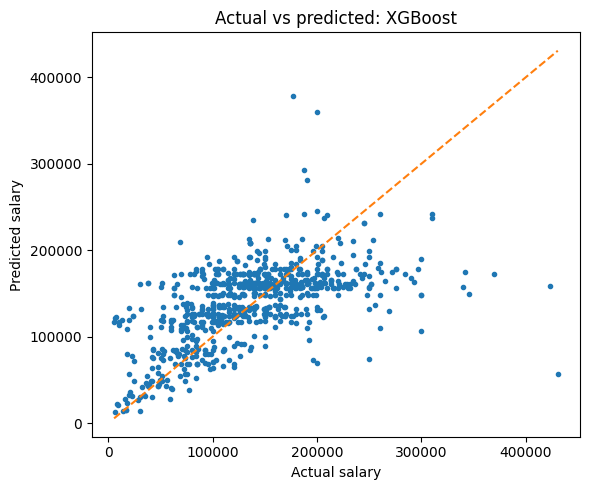

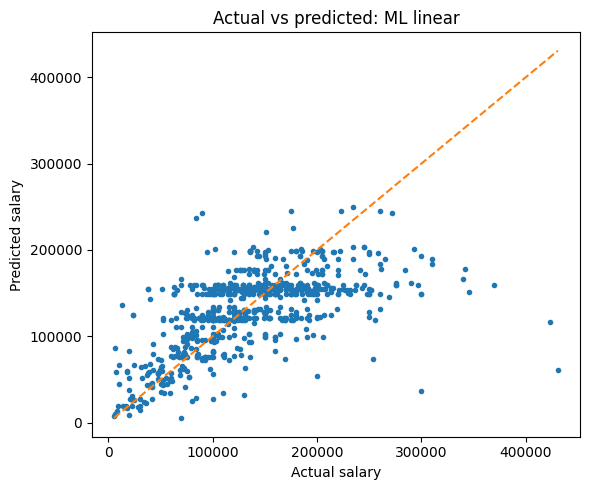

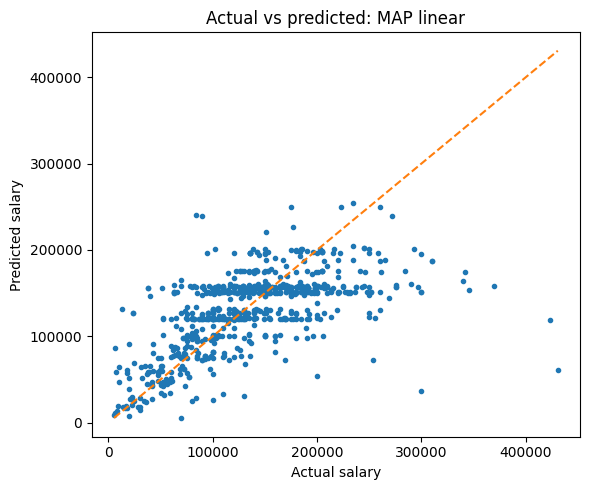

In [142]:
preds = {
    "XGBoost": pred_xgb_test,
    "ML linear": pred_ml_test,
    "MAP linear": pred_map_test,
}

for name, pred in preds.items():
    plt.figure(figsize=(6, 5))
    plt.plot(y_test_salary, pred, ".")
    plt.plot(
        [y_test_salary.min(), y_test_salary.max()],
        [y_test_salary.min(), y_test_salary.max()],
        "--"
    )
    plt.xlabel("Actual salary")
    plt.ylabel("Predicted salary")
    plt.title(f"Actual vs predicted: {name}")
    plt.tight_layout()
    plt.show()

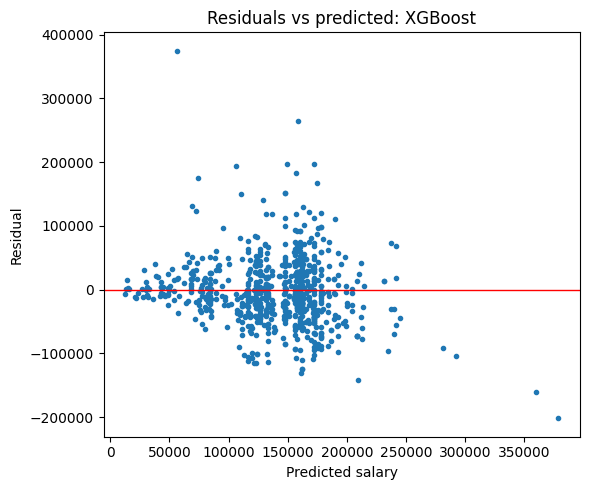

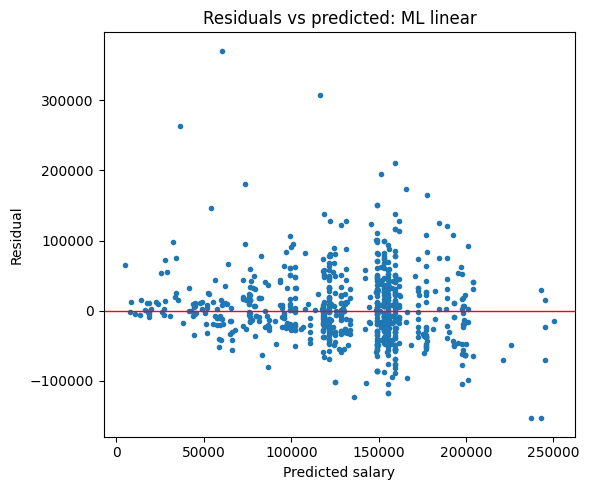

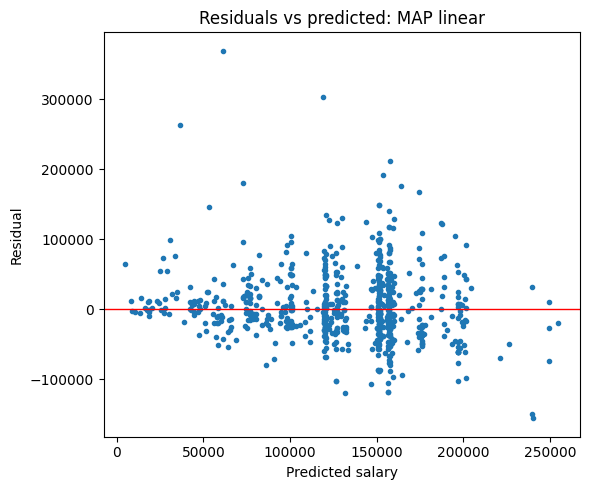

In [143]:
for name, pred in preds.items():
    resid = y_test_salary - pred

    plt.figure(figsize=(6, 5))
    plt.plot(pred, resid, ".")
    plt.axhline(0, color="red", lw=1)
    plt.xlabel("Predicted salary")
    plt.ylabel("Residual")
    plt.title(f"Residuals vs predicted: {name}")
    plt.tight_layout()
    plt.show()

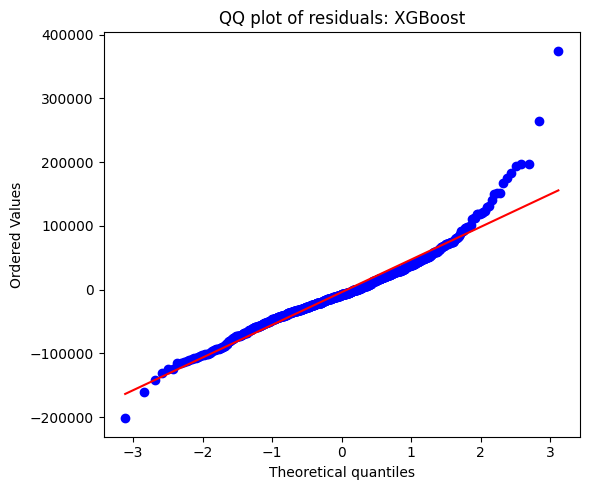

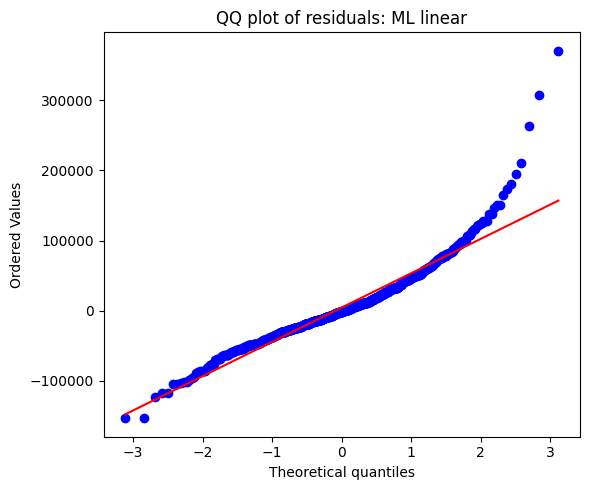

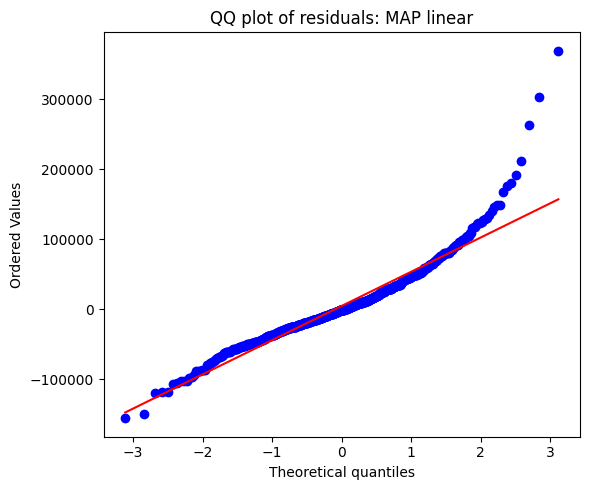

In [144]:
for name, pred in preds.items():
    resid = y_test_salary - pred

    plt.figure(figsize=(6, 5))
    stats.probplot(resid, dist="norm", plot=plt)
    plt.title(f"QQ plot of residuals: {name}")
    plt.tight_layout()
    plt.show()

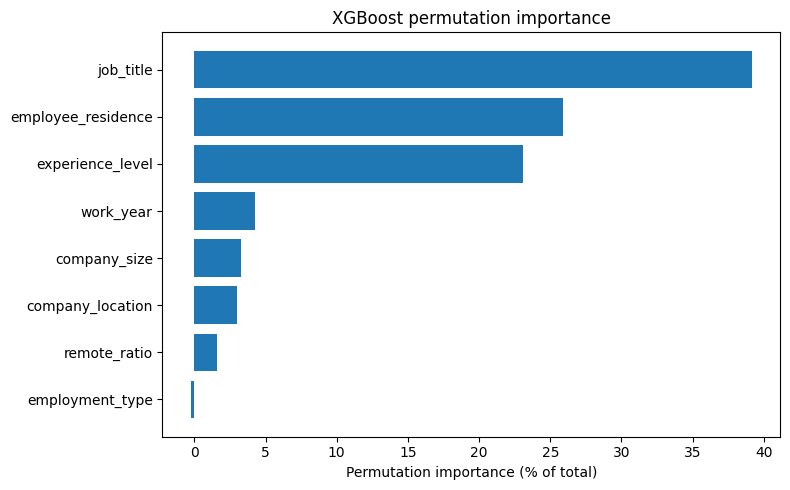

In [145]:
r = permutation_importance(
    model,
    X_test_xgb,
    y_test_salary,
    n_repeats=50,
    random_state=0
)

pi = pd.Series(
    r.importances_mean,
    index=X_test_xgb.columns
).sort_values()

pi_pct = pi / pi.sum() * 100

plt.figure(figsize=(8, 5))
plt.barh(pi_pct.index, pi_pct.values)
plt.xlabel("Permutation importance (% of total)")
plt.title("XGBoost permutation importance")
plt.tight_layout()
plt.show()

In [146]:
coef_compare = pd.DataFrame({
    "ML": theta_ml,
    "MAP": theta_map,
    "prior_mean": mu0,
    "prior_sd": prior_sd,
})

# Show strongest absolute MAP coefficients
print(
    coef_compare
    .assign(abs_MAP=lambda d: d["MAP"].abs())
    .sort_values("abs_MAP", ascending=False)
    .head(25)
)

                                                     ML       MAP  prior_mean  \
employee_residence_IL                          2.681972  2.685443     0.00000   
employee_residence_CH                          2.139726  2.149445     0.00000   
const                                        -43.449689  1.997549    11.70022   
employee_residence_CZ                         -1.827770 -1.829678     0.00000   
employee_residence_CN                          1.792379  1.823655     0.00000   
company_location_SG                           -1.861307 -1.819592     0.00000   
job_title_Marketing Data Analyst               1.816388  1.747606     0.00000   
job_title_Data Analytics Lead                  1.779504  1.697455     0.00000   
company_location_CH                           -1.684798 -1.664059     0.00000   
employee_residence_SG                          1.697000  1.658804     0.00000   
job_title_Data Science Tech Lead               1.702336  1.626501     0.00000   
job_title_Lead Machine Learn

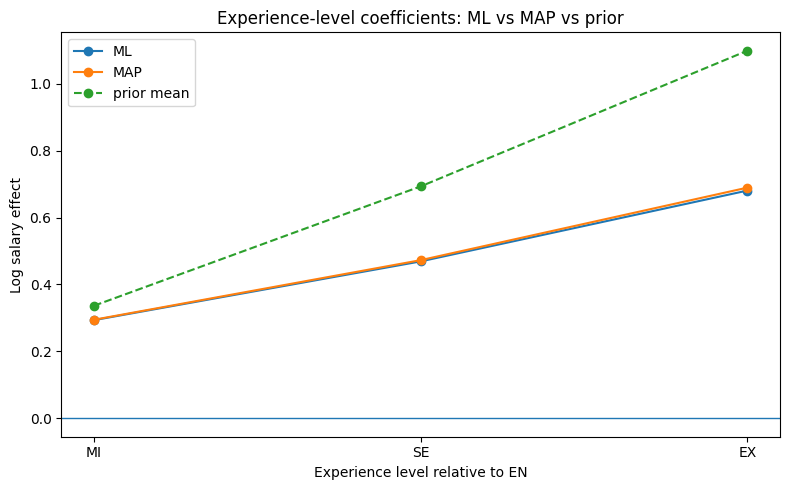

In [147]:
exp_cols = [c for c in coef_compare.index if "experience_level" in c]

plot_coef = coef_compare.loc[exp_cols, ["ML", "MAP", "prior_mean"]].copy()
plot_coef.index = plot_coef.index.str.replace("experience_level_", "", regex=False)

plt.figure(figsize=(8, 5))
plt.plot(plot_coef.index, plot_coef["ML"], marker="o", label="ML")
plt.plot(plot_coef.index, plot_coef["MAP"], marker="o", label="MAP")
plt.plot(plot_coef.index, plot_coef["prior_mean"], marker="o", linestyle="--", label="prior mean")

plt.axhline(0, linewidth=1)
plt.title("Experience-level coefficients: ML vs MAP vs prior")
plt.xlabel("Experience level relative to EN")
plt.ylabel("Log salary effect")
plt.legend()
plt.tight_layout()
plt.show()